In [2]:
import os
from pathlib import Path
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import random
import numpy as np
import pandas as pd
from scipy.stats import entropy
from pathlib import Path

In [ ]:


root = r"C://Users//sarva//OneDrive//Desktop//GAFIS//dataset_img//SocoFing_Real//Real//Real"

rows = []

for subject_folder in Path(root).iterdir():

    if not subject_folder.is_dir():
        continue

    subject = subject_folder.name

    gender = "Unknown"

    if "__M" in subject:
        gender = "Male"

    elif "__F" in subject:
        gender = "Female"

    images = list(subject_folder.glob("*.BMP"))

    for img_path in images:

        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        h, w = img.shape

        rows.append({
            "subject": subject,
            "gender": gender,
            "height": h,
            "width": w
        })

df = pd.DataFrame(rows)

print("Total Images :", len(df))
print("Total Subjects :", df["subject"].nunique())

print("\nGender Distribution")
print(df["gender"].value_counts())

print("\nResolution Statistics")
print(df[["height","width"]].describe())

Total Images : 6000
Total Subjects : 600

Gender Distribution
gender
Male      4770
Female    1230
Name: count, dtype: int64

Resolution Statistics
            height        width
count  6000.000000  6000.000000
mean    104.430000    97.063333
std      16.638847    12.372476
min     103.000000    96.000000
25%     103.000000    96.000000
50%     103.000000    96.000000
75%     103.000000    96.000000
max     298.000000   241.000000


In [6]:
subject_counts = df.groupby("subject").size()

print(subject_counts.describe())

count    600.0
mean      10.0
std        0.0
min       10.0
25%       10.0
50%       10.0
75%       10.0
max       10.0
dtype: float64


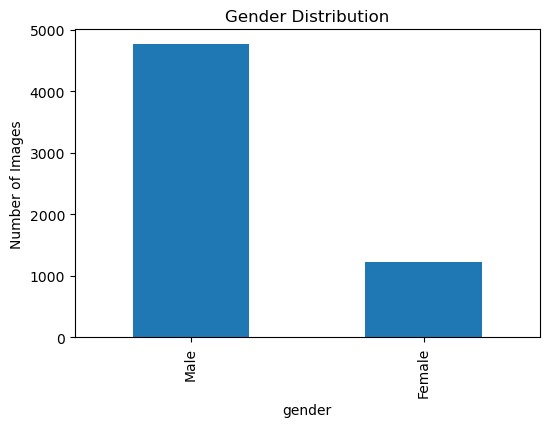

In [ ]:


gender_counts = df["gender"].value_counts()

plt.figure(figsize=(6,4))
gender_counts.plot(kind="bar")

plt.title("Gender Distribution")
plt.ylabel("Number of Images")

plt.show()

In [9]:
male_pct = 4770/6000*100
female_pct = 1230/6000*100

print(male_pct, female_pct)

79.5 20.5


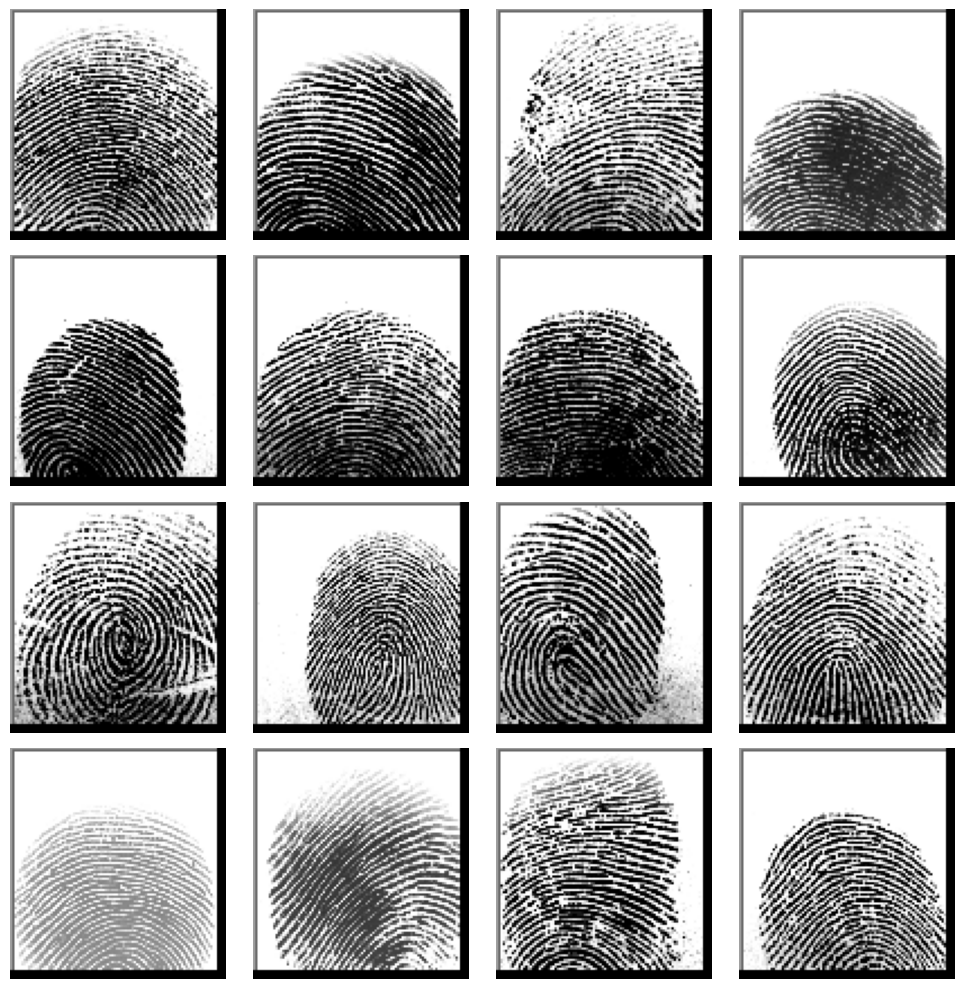

In [ ]:


sample_paths = random.sample(
    list(Path(root).rglob("*.BMP")),
    16
)

fig, axes = plt.subplots(4,4, figsize=(10,10))

for ax, path in zip(axes.flatten(), sample_paths):

    img = cv2.imread(str(path),0)

    ax.imshow(img, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:


results = []

for img_path in Path(root).rglob("*.BMP"):

    img = cv2.imread(str(img_path),0)

    mean_intensity = img.mean()

    contrast = img.std()

    hist = cv2.calcHist(
        [img],
        [0],
        None,
        [256],
        [0,256]
    )

    ent = entropy(hist.ravel()+1)

    blur_score = cv2.Laplacian(
        img,
        cv2.CV_64F
    ).var()

    results.append([
        mean_intensity,
        contrast,
        ent,
        blur_score
    ])

quality_df = pd.DataFrame(
    results,
    columns=[
        "MeanIntensity",
        "Contrast",
        "Entropy",
        "BlurScore"
    ]
)

quality_df.describe()
# Quality metrics

,MeanIntensity,Contrast,Entropy,BlurScore
count,6000.000000,6000.000000,6000.000000,6000.000000
mean,142.777343,103.808374,3.609110,58055.867235
std,22.955230,6.655517,0.401726,16871.983811
min,37.398362,71.618899,1.748449,4873.530807
25%,130.047507,100.733913,3.365154,47633.672735
50%,144.105886,105.285218,3.648036,59622.224009
75%,158.463542,108.241042,3.873970,69581.353459
max,220.481897,120.764147,4.788679,112282.170409


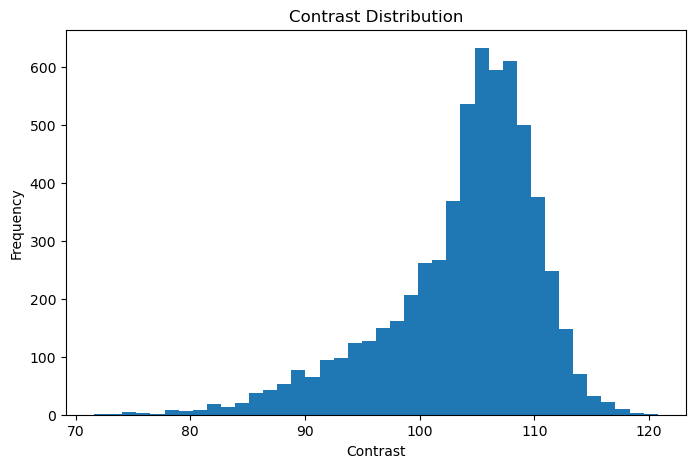

In [ ]:
# Contrast Distribution

plt.figure(figsize=(8,5))
plt.hist(
    quality_df["Contrast"],
    bins=40
)

plt.title("Contrast Distribution")
plt.xlabel("Contrast")
plt.ylabel("Frequency")

plt.show()

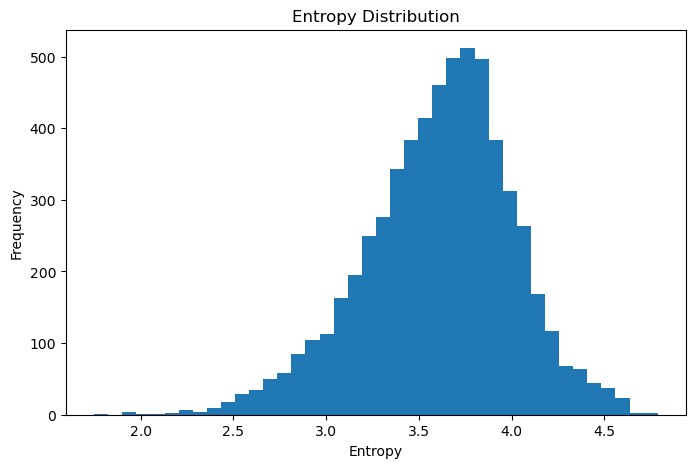

In [12]:
plt.figure(figsize=(8,5))
plt.hist(
    quality_df["Entropy"],
    bins=40
)

plt.title("Entropy Distribution")
plt.xlabel("Entropy")
plt.ylabel("Frequency")

plt.show()

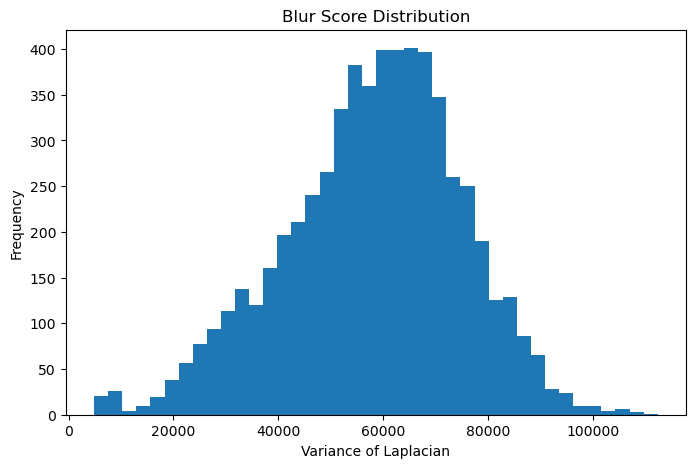

In [13]:
plt.figure(figsize=(8,5))
plt.hist(
    quality_df["BlurScore"],
    bins=40
)

plt.title("Blur Score Distribution")
plt.xlabel("Variance of Laplacian")
plt.ylabel("Frequency")

plt.show()

In [14]:
df.groupby(["height","width"]).size().sort_values(ascending=False).head(20)

height  width
103     96       5956
298     241        44
dtype: int64

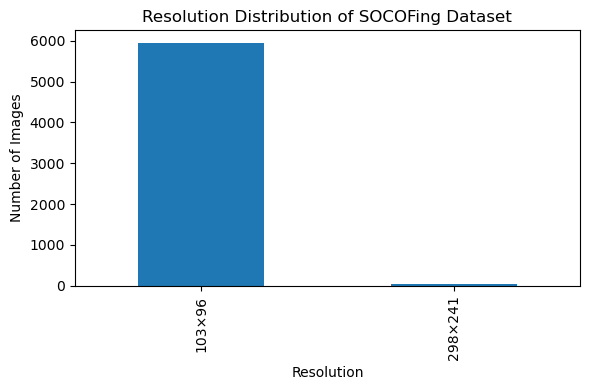

In [3]:
resolution_counts = pd.Series({
    "103×96": 5956,
    "298×241": 44
})

plt.figure(figsize=(6,4))
resolution_counts.plot(kind='bar')

plt.title("Resolution Distribution of SOCOFing Dataset")
plt.xlabel("Resolution")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

### Preprocessing SOCOFing


In [ ]:

root = r"C://Users//sarva//OneDrive//Desktop//GAFIS//dataset_img//SocoFing_Real//Real//Real"

all_images = list(Path(root).rglob("*.BMP"))

sample_path = random.choice(all_images)

print(sample_path)

C:\Users\sarva\OneDrive\Desktop\GAFIS\dataset_img\SocoFing_Real\Real\Real\169__F\169__F_Right_little_finger.BMP


In [ ]:
def preprocess(img):

    img = cv2.resize(img,(256,256))

    img = apply_clahe(img)

    img = gabor_enhance(img)

    img = cv2.normalize(
        img,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    return img

In [32]:
def preprocess(img):

    img = cv2.resize(img,(256,256))

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    img = clahe.apply(img)

    img = cv2.GaussianBlur(
        img,
        (3,3),
        0
    )

    img = cv2.normalize(
        img,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    return img

In [33]:
edges = cv2.Laplacian(
    img,
    cv2.CV_64F
)

edges = np.uint8(np.absolute(edges))

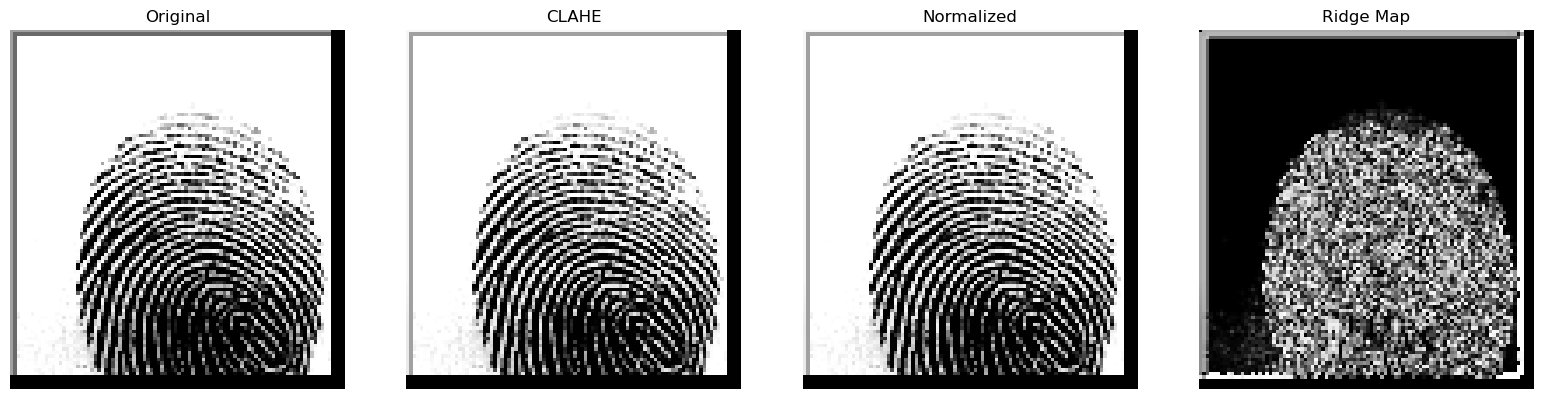

In [35]:
sample = cv2.imread(str(sample_path), 0)

clahe = apply_clahe(sample)

normalized = cv2.normalize(
    clahe,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

edges = cv2.Laplacian(
    normalized,
    cv2.CV_64F
)

edges = np.uint8(np.absolute(edges))

fig, ax = plt.subplots(1,4, figsize=(16,4))

ax[0].imshow(sample, cmap='gray')
ax[0].set_title("Original")

ax[1].imshow(clahe, cmap='gray')
ax[1].set_title("CLAHE")

ax[2].imshow(normalized, cmap='gray')
ax[2].set_title("Normalized")

ax[3].imshow(edges, cmap='gray')
ax[3].set_title("Ridge Map")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

### Degradation

In [ ]:


def generate_latent(img):

    latent = img.copy()

    # Blur
    if random.random() < 0.8:
        latent = cv2.GaussianBlur(
            latent,
            (5,5),
            random.uniform(1,3)
        )

    # Contrast loss
    alpha = random.uniform(0.5,0.9)

    latent = cv2.convertScaleAbs(
        latent,
        alpha=alpha
    )

    # Random occlusion
    h,w = latent.shape

    occ_w = random.randint(
        w//5,
        w//3
    )

    occ_h = random.randint(
        h//5,
        h//3
    )

    x = random.randint(0,w-occ_w)
    y = random.randint(0,h-occ_h)

    latent[y:y+occ_h,x:x+occ_w] = 255

    return latent

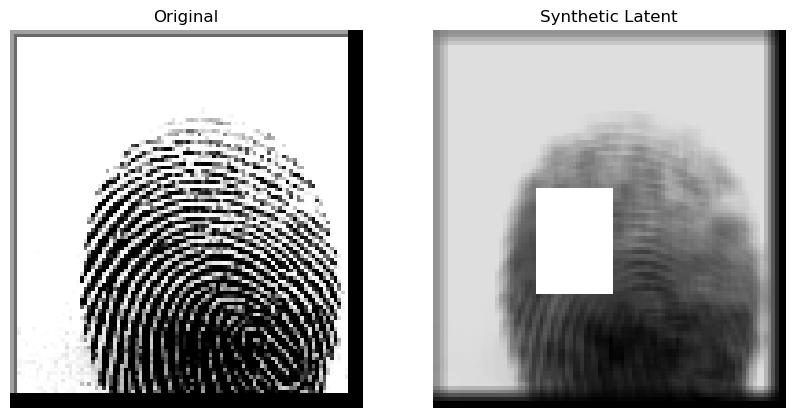

In [37]:
latent = generate_latent(sample)

fig,ax = plt.subplots(1,2,figsize=(10,5))

ax[0].imshow(sample,cmap='gray')
ax[0].set_title("Original")

ax[1].imshow(latent,cmap='gray')
ax[1].set_title("Synthetic Latent")

for a in ax:
    a.axis("off")

plt.show()

In [ ]:
# ---------------------------
# Quality Metrics Function
# ---------------------------

def compute_metrics(img):

    mean_intensity = img.mean()

    contrast = img.std()

    hist = cv2.calcHist(
        [img],
        [0],
        None,
        [256],
        [0,256]
    )

    ent = entropy(hist.ravel() + 1)

    blur_score = cv2.Laplacian(
        img,
        cv2.CV_64F
    ).var()

    return {
        "MeanIntensity": round(mean_intensity,2),
        "Contrast": round(contrast,2),
        "Entropy": round(ent,2),
        "BlurScore": round(blur_score,2)
    }


# ---------------------------
# Latent Generator
# ---------------------------

def generate_latent(img, level="mild"):

    latent = img.copy()

    if level == "mild":
        sigma = 1
        occ = 0.10

    elif level == "moderate":
        sigma = 2
        occ = 0.25

    else:
        sigma = 3
        occ = 0.40

    latent = cv2.GaussianBlur(
        latent,
        (5,5),
        sigma
    )

    latent = cv2.convertScaleAbs(
        latent,
        alpha=0.7
    )

    h,w = latent.shape

    occ_w = int(w * occ)
    occ_h = int(h * occ)

    x = np.random.randint(0,w-occ_w)
    y = np.random.randint(0,h-occ_h)

    latent[y:y+occ_h, x:x+occ_w] = 255

    return latent


# ---------------------------
# Load Sample
# ---------------------------

sample = cv2.imread(str(sample_path),0)

mild = generate_latent(sample,"mild")

moderate = generate_latent(sample,"moderate")

severe = generate_latent(sample,"severe")


# ---------------------------
# Evaluation Table
# ---------------------------

results = []

results.append(
    ["Original", *compute_metrics(sample).values()]
)

results.append(
    ["Mild", *compute_metrics(mild).values()]
)

results.append(
    ["Moderate", *compute_metrics(moderate).values()]
)

results.append(
    ["Severe", *compute_metrics(severe).values()]
)

columns = [
    "Image",
    "MeanIntensity",
    "Contrast",
    "Entropy",
    "BlurScore"
]

metrics_df = pd.DataFrame(
    results,
    columns=columns
)

print(metrics_df)

metrics_df

      Image  MeanIntensity  Contrast  Entropy  BlurScore
0  Original         161.05    109.28     2.96   54712.86
1      Mild         113.18     63.65     4.10     382.90
2  Moderate         117.80     68.58     4.18     460.05
3    Severe         143.53     73.21     3.63    1333.41


,Image,MeanIntensity,Contrast,Entropy,BlurScore
0,Original,161.05,109.28,2.96,54712.86
1,Mild,113.18,63.65,4.10,382.90
2,Moderate,117.80,68.58,4.18,460.05
3,Severe,143.53,73.21,3.63,1333.41


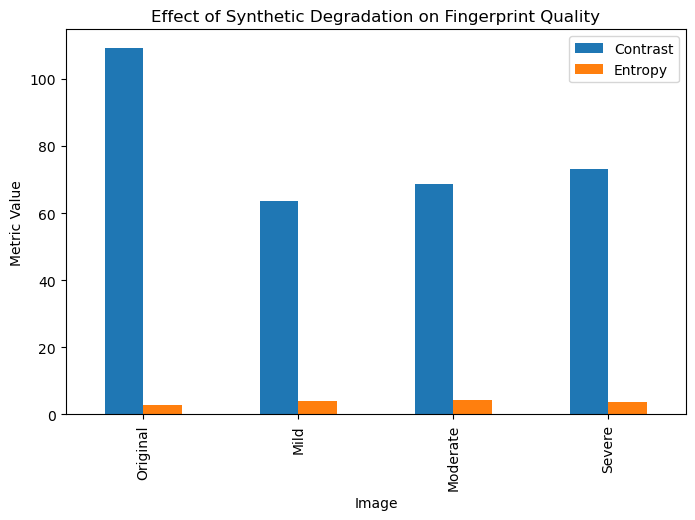

In [ ]:
metrics_df.plot(
    x="Image",
    y=["Contrast","Entropy"],
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Effect of Synthetic Degradation on Fingerprint Quality"
)

plt.ylabel("Metric Value")

plt.show()

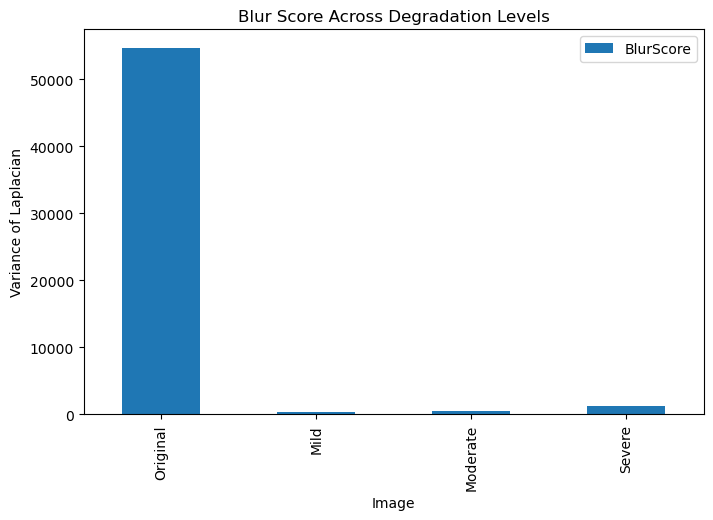

In [42]:
metrics_df.plot(
    x="Image",
    y="BlurScore",
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Blur Score Across Degradation Levels"
)

plt.ylabel(
    "Variance of Laplacian"
)

plt.show()

# PolyU real world degradation


In [4]:
from pathlib import Path
import cv2

polyu_root = "C://Users//sarva//OneDrive//Desktop//GAFIS//dataset_img//PolyU_Noisy//PolyU-Real-World-Noisy-Images-Dataset-master//CroppedImages"

files = list(Path(polyu_root).rglob("*"))

print("Total files:", len(files))

for f in files[:5]:
    print(f)

Total files: 200
C:\Users\sarva\OneDrive\Desktop\GAFIS\dataset_img\PolyU_Noisy\PolyU-Real-World-Noisy-Images-Dataset-master\CroppedImages\Canon5D2_5_160_3200_chair_11_mean.JPG
C:\Users\sarva\OneDrive\Desktop\GAFIS\dataset_img\PolyU_Noisy\PolyU-Real-World-Noisy-Images-Dataset-master\CroppedImages\Canon5D2_5_160_3200_chair_11_real.JPG
C:\Users\sarva\OneDrive\Desktop\GAFIS\dataset_img\PolyU_Noisy\PolyU-Real-World-Noisy-Images-Dataset-master\CroppedImages\Canon5D2_5_160_3200_chair_14_mean.JPG
C:\Users\sarva\OneDrive\Desktop\GAFIS\dataset_img\PolyU_Noisy\PolyU-Real-World-Noisy-Images-Dataset-master\CroppedImages\Canon5D2_5_160_3200_chair_14_real.JPG
C:\Users\sarva\OneDrive\Desktop\GAFIS\dataset_img\PolyU_Noisy\PolyU-Real-World-Noisy-Images-Dataset-master\CroppedImages\Canon5D2_5_160_3200_chair_5_mean.JPG


(512, 512, 3)


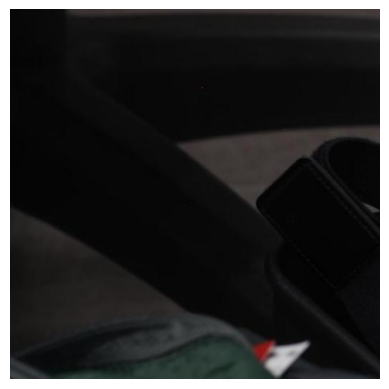

In [5]:
import matplotlib.pyplot as plt

img = cv2.imread(str(files[0]))

print(img.shape)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [6]:
import cv2
import numpy as np
from pathlib import Path
import os

cropped = Path("C://Users//sarva//OneDrive//Desktop//GAFIS//dataset_img//PolyU_Noisy//PolyU-Real-World-Noisy-Images-Dataset-master//CroppedImages")

save_dir = Path("NoiseLibrary")
save_dir.mkdir(exist_ok=True)

mean_files = sorted(cropped.glob("*_mean.JPG"))

count = 0

for mean_path in mean_files:

    real_path = Path(
        str(mean_path).replace("_mean.JPG", "_real.JPG")
    )

    if not real_path.exists():
        continue

    mean = cv2.imread(str(mean_path))
    real = cv2.imread(str(real_path))

    mean = mean.astype(np.float32)
    real = real.astype(np.float32)

    noise = real - mean

    np.save(
        save_dir/f"noise_{count:03d}.npy",
        noise
    )

    count += 1

print("Noise maps saved:", count)

Noise maps saved: 100


In [9]:
from pathlib import Path

noise_files = list(Path("NoiseLibrary").glob("*.npy"))

print(len(noise_files))
print(noise_files[:5])

100
[WindowsPath('NoiseLibrary/noise_000.npy'), WindowsPath('NoiseLibrary/noise_001.npy'), WindowsPath('NoiseLibrary/noise_002.npy'), WindowsPath('NoiseLibrary/noise_003.npy'), WindowsPath('NoiseLibrary/noise_004.npy')]


In [10]:
import random

random_noise_file = random.choice(noise_files)

print(random_noise_file)

NoiseLibrary\noise_023.npy


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

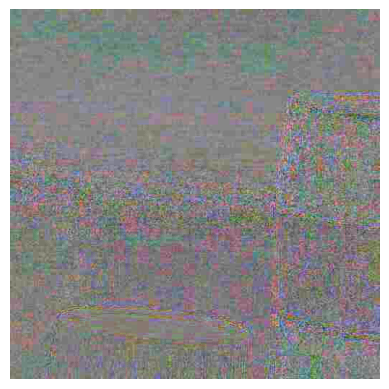

In [11]:
noise = np.load(random_noise_file)

display = noise - noise.min()
display /= display.max()
display *= 255

display = display.astype(np.uint8)

plt.imshow(cv2.cvtColor(display, cv2.COLOR_BGR2RGB))
plt.axis("off")

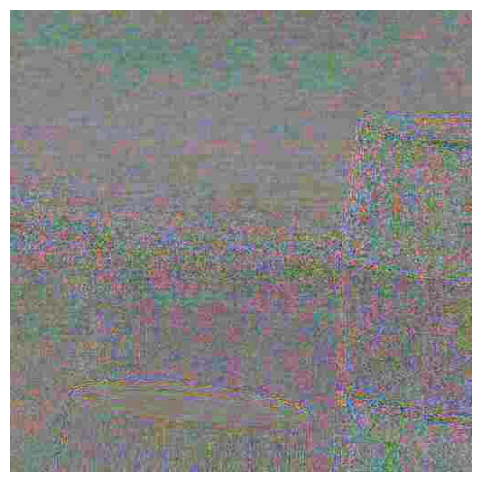

In [12]:
import matplotlib.pyplot as plt

display = noise.copy()

display -= display.min()
display /= display.max()
display *= 255

display = display.astype(np.uint8)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(display, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [13]:
noise = np.load(random_noise_file)

noise = cv2.resize(
    noise,
    (256,256)
)

noise = cv2.cvtColor(
    noise,
    cv2.COLOR_BGR2GRAY
)

alpha = np.random.uniform(
    0.10,
    0.25
)

fp = degraded.astype(np.float32)

fp += alpha * noise

fp = np.clip(fp,0,255)

fp = fp.astype(np.uint8)

NameError: name 'degraded' is not defined